In [21]:
import pandas as pd 
from sklearn.linear_model import LogisticRegression

In [12]:
data = pd.read_csv('C:\\Users\\Liman\\Downloads\\Data.csv')
data.head()

,gmat,gpa,work_experience,admitted
0,780,4.0,3,yes
1,750,3.9,4,yes
2,690,3.3,3,no
3,710,3.7,5,yes
4,680,3.9,4,no


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gmat             40 non-null     int64  
 1   gpa              40 non-null     float64
 2   work_experience  40 non-null     int64  
 3   admitted         40 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 1.4+ KB


In [14]:
data.isnull().sum()

gmat               0
gpa                0
work_experience    0
admitted           0
dtype: int64

In [15]:
duplicate = data.duplicated().sum()
print(duplicate)

2


In [18]:
data.drop_duplicates(inplace=True)

In [ ]:
data["admitted"]=data["admitted"].map({"yes": 1, "no": 0})
#convert admitted variable into numerical
data.head()

,gmat,gpa,work_experience,admitted
0,780,4.0,3,1
1,750,3.9,4,1
2,690,3.3,3,0
3,710,3.7,5,1
4,680,3.9,4,0


In [27]:
#import relevant libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
#features extraction
x = data[['gmat', 'gpa','work_experience']]
y = data['admitted']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)  
#splitting data with test size of 25%
logreg = LogisticRegression()   #build our logistic model
logreg.fit(x_train, y_train)  #fitting training data
y_pred  = logreg.predict(x_test)    #testing model’s performance
print("Accuracy={:.2f}".format(logreg.score(x_test, y_test)))

Accuracy=0.80


<Axes: xlabel='gmat', ylabel='admitted'>

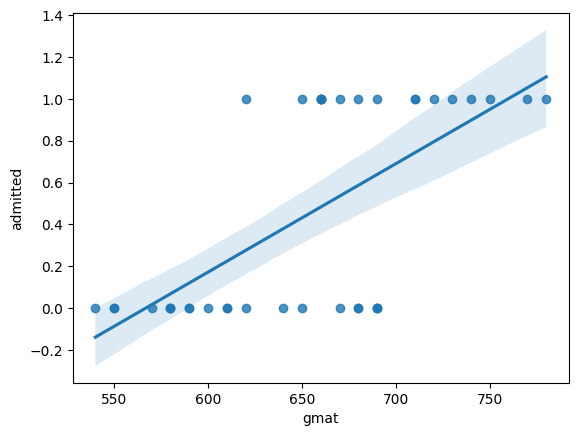

In [28]:
import seaborn as sns
sns.regplot(x='gmat',y='admitted',data=data)

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      0.50      0.67         4

    accuracy                           0.80        10
   macro avg       0.88      0.75      0.76        10
weighted avg       0.85      0.80      0.78        10



KNN